# 03 · Promotion Readiness Assessment — Logistic Regression

**Goal** — produce an objective **promotion-readiness score** from performance history
(`performance_score`, `performance_last_year`, `manager_rating`), training completions
(`training_hours_last_year`, `mentoring_sessions`), certifications (`certifications_count`,
`skill_assessment_score`) and tenure (`years_at_company`, `years_in_current_role`,
`years_since_last_promotion`).

**Algorithm — Logistic Regression** (`LogisticRegression`). Chosen because promotion is a
high-stakes, must-be-defensible decision: logistic regression yields a calibrated probability
and transparent, auditable coefficients (odds ratios) HR can explain to employees — exactly
what an "objective readiness score" needs. Rationale + citations in
`../MODEL-JUSTIFICATION.md`. Binary classification on `employee_promotion_prediction.csv`
(~100k rows, ~10% promoted — strongly imbalanced).

> **Leakage note:** `salary_increase_percent` is dropped — a raise is granted *as part of* a
> promotion, so it would leak the outcome.

Logged to `logs/promotion*.log`; artifacts under `artifacts/promotion/`.

In [1]:
# --- environment & logged run -------------------------------------------------------
import sys
from pathlib import Path

# notebooks/ live one level below the model root where synapse_ml.py sits
HERE = Path.cwd()
MODEL_DIR = HERE if (HERE / "synapse_ml.py").exists() else HERE.parent
sys.path.insert(0, str(MODEL_DIR))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)

import synapse_ml as sm
run = sm.start_run("promotion")   # opens logs/promotion_<ts>.log + artifacts/promotion/
log = run.log

INFO    | ==============================================================================


INFO    | RUN START · model=promotion · 2026-06-23T03:19:26


INFO    | python=3.14.4 · platform=Windows-11-10.0.26200-SP0


INFO    | log file=C:\Users\Earl Kian\Documents\Project\synapse\model\logs\promotion_20260623_031926.log


INFO    | artifacts=C:\Users\Earl Kian\Documents\Project\synapse\model\artifacts\promotion


INFO    | libs · numpy=2.5.0, pandas=2.3.3, scipy=1.18.0, sklearn=1.9.0, matplotlib=3.11.0, seaborn=0.13.2


## 1 · Load data

In [2]:
df = run.load_csv("employee_promotion_prediction.csv")
print(df.shape)
df.head()

INFO    | loading data · C:\Users\Earl Kian\Documents\Project\synapse\model\employee_promotion_prediction.csv


INFO    | loaded shape=(100000, 43) · columns=43


(100000, 43)


,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,years_since_last_promotion,team_size,performance_score,performance_last_year,performance_two_years_ago,manager_rating,peer_feedback_score,projects_completed,kpi_achievement_percent,innovation_score,leadership_score,problem_solving_score,avg_monthly_hours,overtime_hours,tasks_completed,deadline_adherence_rate,meeting_hours_per_month,remote_work_ratio,training_hours_last_year,certifications_count,skill_assessment_score,cross_department_projects,mentoring_sessions,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,4,10,7,100.000000,100.000000,85.964051,4.026107,3.931381,4,90.518924,70.395227,83.068321,46.634645,150.935199,20.217535,24.308108,0.861171,24.534005,0.354708,25.361303,2,67.560751,1,3,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,5,3,8,72.008233,78.270415,70.963042,4.135957,3.497259,9,58.125175,74.505077,76.840144,52.749119,177.389542,28.581193,59.627936,0.806096,29.574865,0.065833,43.760654,4,74.851443,6,2,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,5,6,6,77.244045,72.824611,59.960718,3.477986,3.235364,7,79.305915,51.705306,62.997452,58.887897,166.931246,17.438137,43.804607,0.702354,29.934692,0.073399,25.275693,2,44.964704,1,4,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,4,2,12,49.061426,54.280668,40.000000,2.353257,1.966977,4,39.937656,50.977286,61.068605,54.714039,136.047654,14.855971,30.485655,0.871308,27.529029,0.129415,33.507680,1,50.993617,2,2,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,2,2,18,89.021698,86.075898,84.834851,4.877006,4.782039,6,78.409429,90.959425,68.382130,45.383453,198.543687,35.706433,40.948985,0.762983,18.535778,0.541355,44.730269,7,78.227838,3,2,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0


In [3]:
import io
_info = io.StringIO()
df.info(buf=_info)
log.info("dataframe info:\n%s", _info.getvalue())
df.describe().T

INFO    | dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   employee_id                 100000 non-null  int64  
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   education_level             100000 non-null  object 
 4   marital_status              100000 non-null  object 
 5   city_tier                   100000 non-null  object 
 6   department                  100000 non-null  object 
 7   employment_type             100000 non-null  object 
 8   years_at_company            100000 non-null  int64  
 9   years_in_current_role       100000 non-null  int64  
 10  years_since_last_promotion  100000 non-null  int64  
 11  team_size                   100000 non-null  int64  
 12  performance_score           100000 non-null  fl

,count,mean,std,min,25%,50%,75%,max
employee_id,100000.0,50000.500000,28867.657797,1.000000,25000.750000,50000.500000,75000.250000,100000.000000
age,100000.0,40.558140,10.951788,22.000000,31.000000,41.000000,50.000000,59.000000
years_at_company,100000.0,5.489030,3.481758,0.000000,3.000000,5.000000,7.000000,30.000000
years_in_current_role,100000.0,2.750630,2.746004,0.000000,1.000000,2.000000,4.000000,28.000000
years_since_last_promotion,100000.0,2.749650,2.733337,0.000000,1.000000,2.000000,4.000000,29.000000
team_size,100000.0,11.014010,4.910633,3.000000,7.000000,11.000000,15.000000,19.000000
performance_score,100000.0,70.097429,14.717013,40.000000,59.499890,69.980013,80.596442,100.000000
performance_last_year,100000.0,68.166798,13.867294,40.000000,58.357646,68.033605,77.791895,100.000000
performance_two_years_ago,100000.0,65.102153,11.773939,40.000000,56.954026,65.018847,73.121749,100.000000
manager_rating,100000.0,3.302642,0.765938,1.000000,2.769433,3.302663,3.837462,5.000000


## 2 · Target & exploratory analysis

INFO    | target=promoted · positive rate=0.100 (10000 of 100000)


INFO    | saved figure · 01_class_balance.png


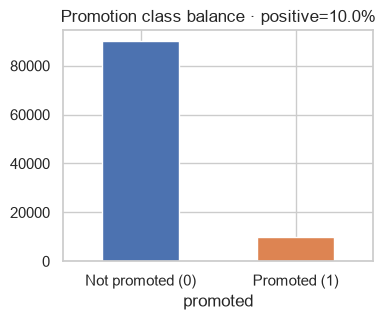

In [4]:
TARGET = "promoted"
ID_COL = "employee_id"
LEAKY = ["salary_increase_percent"]   # post-promotion artefact -> dropped
DROP = [ID_COL] + LEAKY

y = df[TARGET].astype(int)
rate = y.mean()
log.info("target=%s · positive rate=%.3f (%d of %d)", TARGET, rate, y.sum(), len(y))

fig, ax = plt.subplots(figsize=(4, 3))
y.value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_xticklabels(["Not promoted (0)", "Promoted (1)"], rotation=0)
ax.set_title(f"Promotion class balance · positive={rate:.1%}")
run.save_fig(fig, "01_class_balance"); plt.show()

INFO    | promotion rate by years_since_last_promotion:
years_since_last_promotion
25    0.500000
21    0.125000
0     0.111048
1     0.109853
18    0.105263
2     0.101173
3     0.099520
4     0.092825
5     0.089096
6     0.087937
8     0.080366
19    0.076923
10    0.076471
7     0.076022
9     0.075758
17    0.072727
13    0.071429
16    0.062500
11    0.061404
14    0.058140
12    0.057534
15    0.054545
22    0.000000
20    0.000000
23    0.000000
26    0.000000
27    0.000000
29    0.000000


INFO    | promotion rate by department:
department
Engineering    0.332135
Sales          0.109806
Marketing      0.086853
Finance        0.079700
Operations     0.044530
HR             0.029016
Support        0.019589


INFO    | saved figure · 02_promotion_by_driver.png


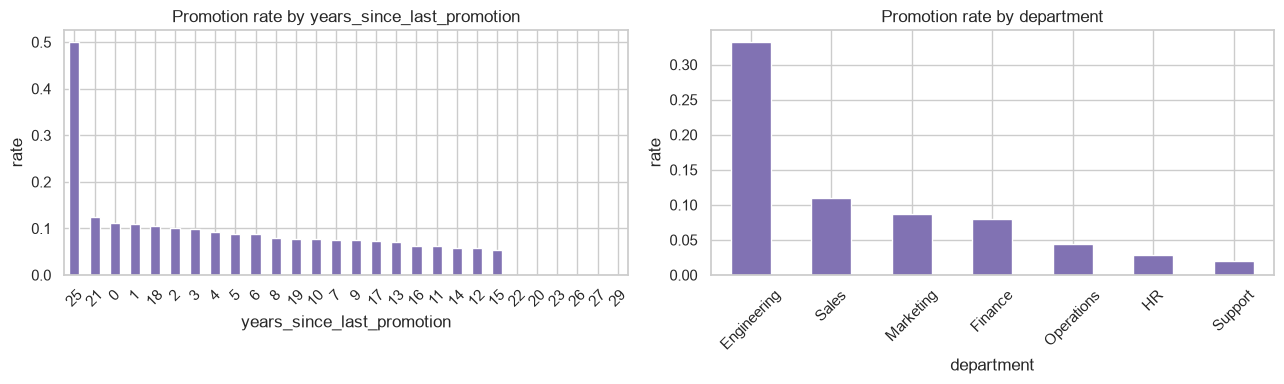

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["years_since_last_promotion", "department"]):
    rates = df.assign(_y=y).groupby(col)["_y"].mean().sort_values(ascending=False)
    log.info("promotion rate by %s:\n%s", col, rates.to_string())
    rates.plot(kind="bar", ax=ax, color="#8172b3")
    ax.set_title(f"Promotion rate by {col}"); ax.set_ylabel("rate")
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout(); run.save_fig(fig, "02_promotion_by_driver"); plt.show()

INFO    | numeric correlation with promotion:
years_since_last_promotion   -0.036665
years_at_company             -0.025622
late_days                    -0.023492
years_in_current_role        -0.016695
age                          -0.002031
remote_work_ratio            -0.000404
team_size                     0.000515
deadline_adherence_rate       0.001063
mentoring_sessions            0.001134
internal_mobility_score       0.002877
cross_department_projects     0.004518
attendance_rate               0.007932
training_hours_last_year      0.010252
certifications_count          0.011325
meeting_hours_per_month       0.025594
problem_solving_score         0.031663
avg_monthly_hours             0.036594
innovation_score              0.046574
performance_two_years_ago     0.049481
skill_assessment_score        0.053693
performance_last_year         0.060786
employee_engagement_score     0.075668
overtime_hours                0.085826
job_satisfaction_score        0.089093
salary            

INFO    | saved figure · 03_numeric_correlation.png


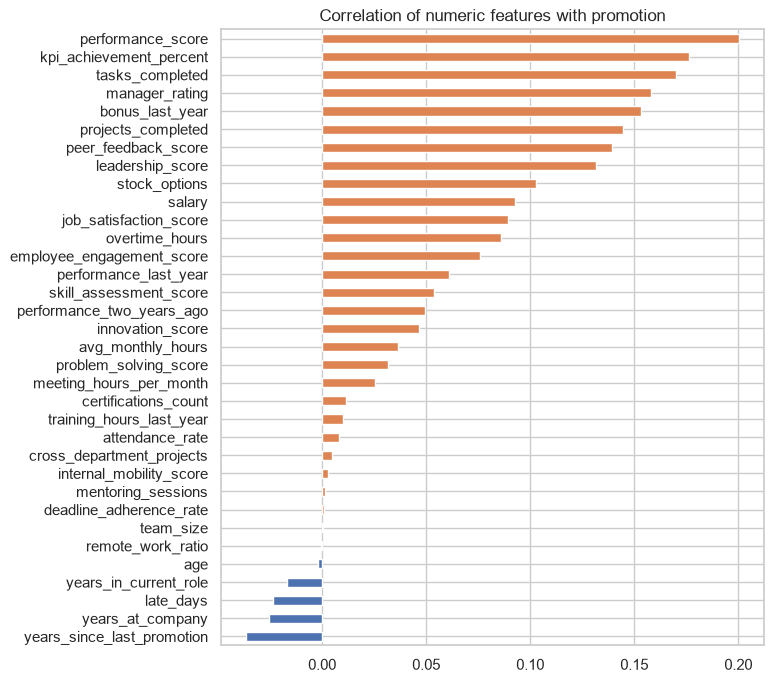

In [6]:
num_df = df.drop(columns=DROP + [TARGET]).select_dtypes("number").assign(_y=y)
corr = num_df.corr()["_y"].drop("_y").sort_values()
log.info("numeric correlation with promotion:\n%s", corr.to_string())

fig, ax = plt.subplots(figsize=(7, 8))
corr.plot(kind="barh", ax=ax, color=np.where(corr > 0, "#dd8452", "#4c72b0"))
ax.set_title("Correlation of numeric features with promotion")
run.save_fig(fig, "03_numeric_correlation"); plt.show()

## 3 · Preprocessing & stratified split

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.drop(columns=DROP + [TARGET])
numeric_cols, categorical_cols = sm.split_feature_types(df.drop(columns=DROP), target=TARGET)
log.info("numeric=%d · categorical=%d %s", len(numeric_cols), len(categorical_cols), categorical_cols)

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     categorical_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
log.info("split · train=%s test=%s", X_train.shape, X_test.shape)

INFO    | numeric=34 · categorical=6 ['gender', 'education_level', 'marital_status', 'city_tier', 'department', 'employment_type']


INFO    | split · train=(80000, 40) test=(20000, 40)


## 4 · Logistic Regression model

Scaling (done in preprocessing) matters for logistic regression's coefficients and
convergence. `class_weight="balanced"` handles the 10% positive rate. Read by 5-fold ROC-AUC.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced")),
])

cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
log.info("CV ROC-AUC = %.4f (+/- %.4f)", cv_auc.mean(), cv_auc.std())
model.fit(X_train, y_train)
log.info("fitted LogisticRegression on %d rows", len(X_train))

INFO    | CV ROC-AUC = 0.9385 (+/- 0.0028)


INFO    | fitted LogisticRegression on 80000 rows


## 5 · Evaluation

In [9]:
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
roc = roc_auc_score(y_test, proba)
pr_auc = average_precision_score(y_test, proba)
report = classification_report(y_test, pred, target_names=["Not promoted", "Promoted"], digits=3)
log.info("test ROC-AUC=%.4f · PR-AUC=%.4f", roc, pr_auc)
log.info("classification report @0.5:\n%s", report)
print(report)

INFO    | test ROC-AUC=0.9406 · PR-AUC=0.6658


INFO    | classification report @0.5:
              precision    recall  f1-score   support

Not promoted      0.985     0.846     0.910     18000
    Promoted      0.390     0.886     0.542      2000

    accuracy                          0.850     20000
   macro avg      0.688     0.866     0.726     20000
weighted avg      0.926     0.850     0.874     20000



              precision    recall  f1-score   support

Not promoted      0.985     0.846     0.910     18000
    Promoted      0.390     0.886     0.542      2000

    accuracy                          0.850     20000
   macro avg      0.688     0.866     0.726     20000
weighted avg      0.926     0.850     0.874     20000



INFO    | saved figure · 04_evaluation_curves.png


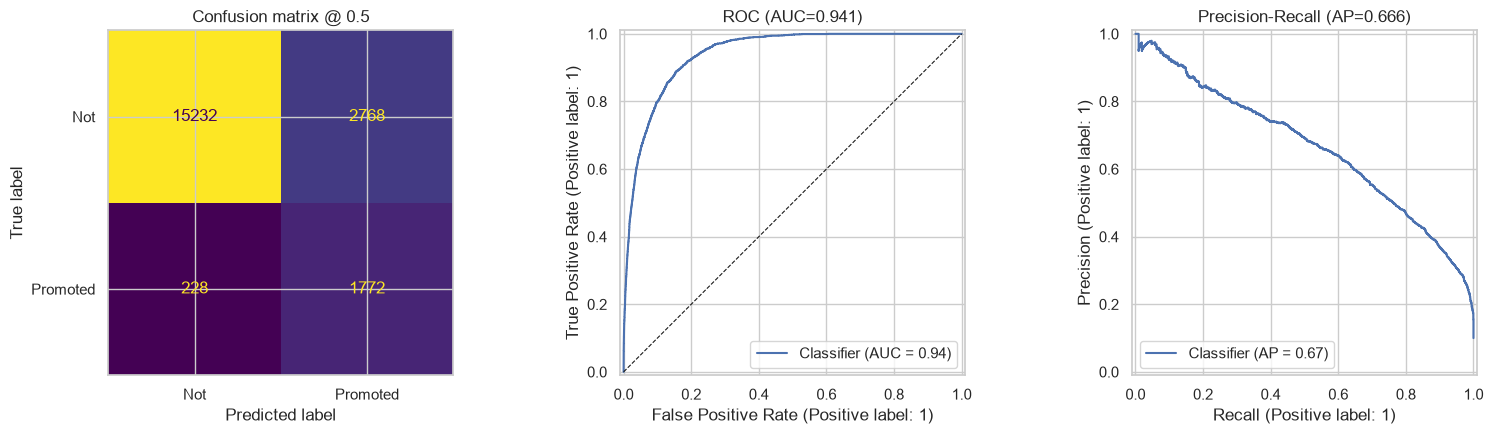

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["Not", "Promoted"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix @ 0.5")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].set_title(f"ROC (AUC={roc:.3f})"); axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[2])
axes[2].set_title(f"Precision-Recall (AP={pr_auc:.3f})")
fig.tight_layout(); run.save_fig(fig, "04_evaluation_curves"); plt.show()

INFO    | odds ratios (exp(coef)):
performance_last_year           0.006362
department_Support              0.129071
department_HR                   0.247423
department_Operations           0.437792
gender_Female                   0.655654
employment_type_Full-time       0.686102
marital_status_Single           0.708158
marital_status_Married          0.713987
employment_type_Contract        0.736939
education_level_PhD             0.740460
gender_Male                     0.771162
years_since_last_promotion      0.772822
city_tier_Tier2                 0.784010
city_tier_Tier1                 0.785150
education_level_Bachelor        0.796016
city_tier_Tier3                 0.821383
education_level_Master          0.857822
late_days                       0.860558
salary                          0.976238
problem_solving_score           0.976510
avg_monthly_hours               0.981390
performance_two_years_ago       0.983757
remote_work_ratio               0.986439
deadline_adherence_rat

INFO    | saved figure · 05_odds_ratios.png


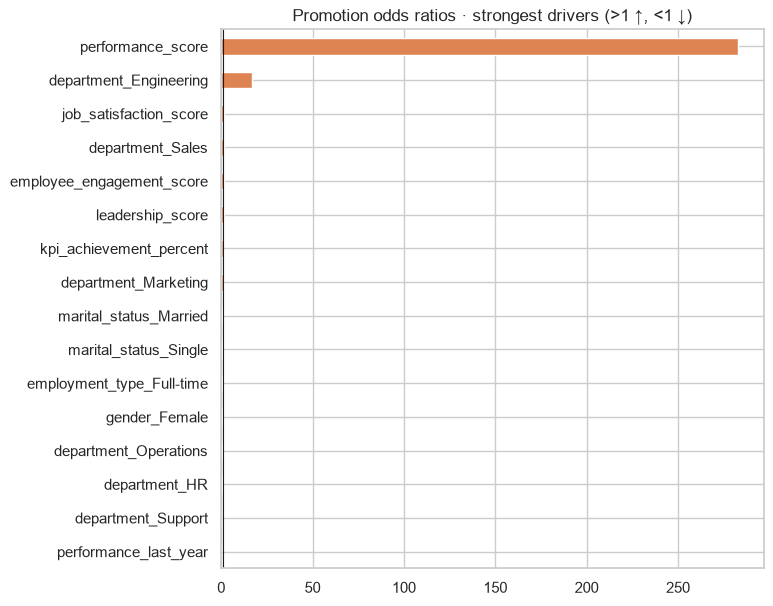

In [11]:
# Logistic-regression coefficients as odds ratios — the interpretability payoff.
ohe = model.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
feat_names = numeric_cols + list(ohe.get_feature_names_out(categorical_cols))
coefs = pd.Series(model.named_steps["clf"].coef_[0], index=feat_names)
odds = np.exp(coefs).sort_values()
log.info("odds ratios (exp(coef)):\n%s", odds.to_string())

top = pd.concat([odds.head(8), odds.tail(8)])
fig, ax = plt.subplots(figsize=(7, 7))
top.plot(kind="barh", ax=ax, color=np.where(top > 1, "#dd8452", "#4c72b0"))
ax.axvline(1.0, color="k", lw=0.8)
ax.set_title("Promotion odds ratios · strongest drivers (>1 ↑, <1 ↓)")
run.save_fig(fig, "05_odds_ratios"); plt.show()

## 6 · Decision-threshold tuning

The shortlist is ranked, so we tune the threshold to maximise F1 on the "Promoted" class
rather than defaulting to 0.5.

INFO    | tuned threshold=0.835 · F1=0.625 · recall=0.635 · precision=0.615


              precision    recall  f1-score   support

Not promoted      0.959     0.956     0.958     18000
    Promoted      0.615     0.635     0.625      2000

    accuracy                          0.924     20000
   macro avg      0.787     0.795     0.791     20000
weighted avg      0.925     0.924     0.924     20000



INFO    | saved figure · 06_threshold_sweep.png


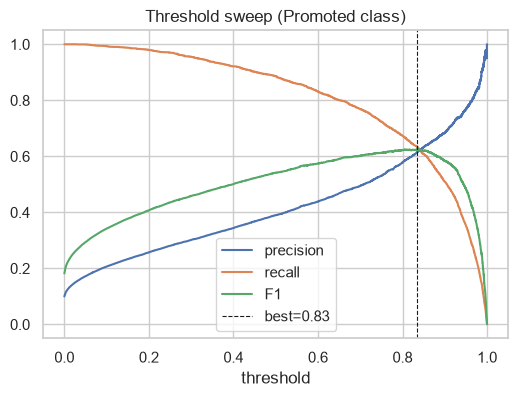

In [12]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, proba)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1s[:-1]))
best_thr = float(thr[best_idx])
log.info("tuned threshold=%.3f · F1=%.3f · recall=%.3f · precision=%.3f",
         best_thr, f1s[best_idx], rec[best_idx], prec[best_idx])
print(classification_report(y_test, (proba >= best_thr).astype(int),
                            target_names=["Not promoted", "Promoted"], digits=3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thr, prec[:-1], label="precision"); ax.plot(thr, rec[:-1], label="recall")
ax.plot(thr, f1s[:-1], label="F1")
ax.axvline(best_thr, color="k", ls="--", lw=0.8, label=f"best={best_thr:.2f}")
ax.set_xlabel("threshold"); ax.set_title("Threshold sweep (Promoted class)"); ax.legend()
run.save_fig(fig, "06_threshold_sweep"); plt.show()

## 7 · Readiness scoring

Turn probabilities into a 0–100 **readiness score** and Low / Medium / High tiers, then
checkpoint the scored roster.

In [13]:
scored = X_test.copy()
scored["readiness_score"] = (proba * 100).round(1)
scored["actual_promoted"] = y_test.values
scored["readiness_tier"] = pd.cut(proba, bins=[-0.01, 0.33, 0.66, 1.01],
                                  labels=["Low", "Medium", "High"])
log.info("readiness tier distribution:\n%s", scored["readiness_tier"].value_counts().sort_index().to_string())
ready = scored.sort_values("readiness_score", ascending=False).head(10)
log.info("top-10 promotion-ready:\n%s",
         ready[["readiness_score", "readiness_tier", "actual_promoted"]].to_string())
run.checkpoint_df(scored.reset_index(names="row_id"), "scored_readiness_roster")
ready[["readiness_score", "readiness_tier", "actual_promoted"]]

INFO    | readiness tier distribution:
readiness_tier
Low       13971
Medium     2672
High       3357


INFO    | top-10 promotion-ready:
       readiness_score readiness_tier  actual_promoted
67115            100.0           High                1
21124            100.0           High                1
57695            100.0           High                1
69759            100.0           High                1
31108            100.0           High                1
46457            100.0           High                1
67864            100.0           High                1
43278            100.0           High                1
84411            100.0           High                1
31865            100.0           High                1


WARNING | parquet unavailable (Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.); wrote CSV instead


INFO    | checkpoint dataframe · scored_readiness_roster.csv · shape=(20000, 44)


,readiness_score,readiness_tier,actual_promoted
67115,100.0,High,1
21124,100.0,High,1
57695,100.0,High,1
69759,100.0,High,1
31108,100.0,High,1
46457,100.0,High,1
67864,100.0,High,1
43278,100.0,High,1
84411,100.0,High,1
31865,100.0,High,1


## 8 · Persist model & metrics

In [14]:
run.save_model(model, "promotion_model")
run.save_metrics({
    "algorithm": "LogisticRegression",
    "cv_roc_auc": float(cv_auc.mean()),
    "test_roc_auc": roc, "test_pr_auc": pr_auc,
    "tuned_threshold": best_thr,
    "tuned_recall_promoted": float(rec[best_idx]),
    "tuned_precision_promoted": float(prec[best_idx]),
    "positive_rate": float(rate),
    "dropped_leaky_features": LEAKY,
    "high_readiness_count": int((scored["readiness_tier"] == "High").sum()),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
})
run.finish(summary=f"LogisticRegression: test ROC-AUC={roc:.3f}, PR-AUC={pr_auc:.3f}, tuned thr={best_thr:.2f}")

INFO    | saved model · promotion_model.joblib (8.8 KB)


INFO    | saved metrics · metrics.json


INFO    |   algorithm                    = LogisticRegression


INFO    |   cv_roc_auc                   = 0.9385


INFO    |   test_roc_auc                 = 0.9406


...

INFO    |   n_train                      = 80000.0000


INFO    |   n_test                       = 20000.0000


INFO    | summary · LogisticRegression: test ROC-AUC=0.941, PR-AUC=0.666, tuned thr=0.83


INFO    | RUN END · model=promotion · elapsed=10.2s


INFO    | ==============================================================================
